# How does PDF(s) and PDF(t) evolve with the transiant time?

In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '..')))
from tools import *
from macro import *

In [3]:
def process_size_bis(histo, Lengthtab, nbins, nmin, nmax):

    last_non_zero = np.nonzero(histo)[0]
    
    mean = np.sum(histo * np.arange(len(histo)))/np.sum(histo)
    
    ndatafit, ndistloglog, nstat = mainfct(histo, Lengthtab, nbins, nmin, nmax)
    Tndist = 10 ** ndistloglog
    Tndatafit = 10 ** ndatafit
    Tnstat = nstat[0]
    
    return Tndist, Tndatafit, Tnstat, last_non_zero[-1], mean

(50,)
(50,)


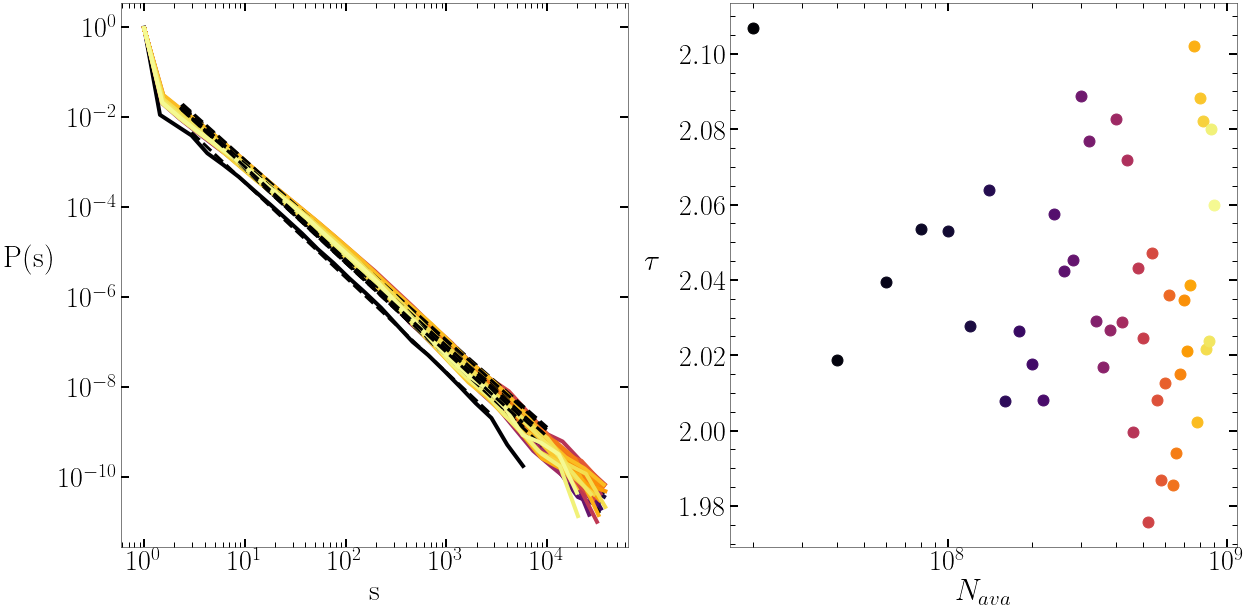

In [4]:
folder = '/data1/DATA_Duplat/Brut/PDF/PD4n1'
params = read_parameters(folder)

nbins = 25
nmin = 2
nmax = 22

L1 = params[0]
L2 = params[1]
nu = params[2]

lengthtab = L1 * L2

# data = read_gz_with_pandas_nrows("/data1/DATA_Duplat/Brut/PDF/PD4n1/trans_histosize.gz", nrows = (256 * 256 + 1) * 45)
data = read_gz_with_pandas_nrows("/data1/DATA_Duplat/Brut/PDF/PD1n12/trans_histosize.gz", nrows = (256 * 256 + 1) * 45)
nbhisto = int(len(data)/(L1 * L2))
data = np.reshape(data, (nbhisto, (L1 * L2 + 1)) )


time = np.array([params[-1][2] * (i+1) for i in range(int(params[-1][1]/params[-1][2]))])
selected_points = np.arange(len(time))

print(np.shape(time))
print(np.shape(selected_points))

# selected_points = [0,1,2,3,4,5, 6, 7, 8, 9]
# time = time[selected_points]

Tnmin = np.array([nmin] * nbhisto)
Tnmax = np.array([nmax] * nbhisto)

results = Parallel(n_jobs=-1)(delayed(process_size_bis)(histo, lengthtab, nbins, nmin, nmax)
                                  for (histo, nmin, nmax) in zip(data, Tnmin, Tnmax))

Tndist = np.zeros((nbhisto,nbins, 2))
Tnstat = np.zeros(nbhisto)
Tnonzero = np.zeros(nbhisto)
Tmean = np.zeros(nbhisto)
Tndatafit = np.zeros((nbhisto,2,2))

NCURVES = nbhisto
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

plt.figure(figsize=(20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)
for j, (Tndist_j, Tndatafit_j, Tnstat_j, Tnzero_j, mean_j) in enumerate(results):
    if j in selected_points:
        Tndist[j] = Tndist_j
        Tndatafit[j] = Tndatafit_j
        Tnstat[j] = Tnstat_j    
        Tnonzero[j] = Tnzero_j
        Tmean[j] = mean_j
        ax1.plot(Tndist[j, :,0][Tndist[j, :,1] != 1],Tndist[j, :,1][Tndist[j, :,1] != 1], color = colors[j], linewidth=4, markersize=6, mfc="none") 
        ax1.plot(Tndatafit[j,:, 0], Tndatafit[j, :,1], color = 'k', linestyle = '--', linewidth = 3)
        ax2.scatter( time[j], -Tnstat[j], color = colors[j], s = 120)
            
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel('s', fontsize=30)
ax1.set_ylabel('P(s) ', fontsize=30, rotation = 0, labelpad = 30)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.set_xscale("log")
ax2.set_xlabel(macros['Nava'], fontsize=30)
ax2.set_ylabel(r'$\tau$', fontsize=30, rotation = 0, labelpad = 30)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
""" plt.legend(title_fontsize = 23, ncol = 2, loc='center left', bbox_to_anchor=(1, 0.5),fontsize = 25) """
plt.show()

## Intertime

In [2]:
nbins = 1000


folderpath = "/data1/DATA_Duplat/Brut/PDF/PD4n1"
param = read_parameters(folderpath)
nu = param[2]
lim_trans = param[-1][1]
delta_trans = param[-1][2]


c = 0
nb = 0
nbline = 0
nbhisto = 44
data = np.zeros(nbhisto*1000)


with gzip.open(f"{folderpath}/trans_histoitime.gz", 'rt') as f:  
    for line in f:
        if line.startswith('#'): 
            nb +=1
            # print(c)
            # print(nb)
            # print(nbline)
            # print("Commentaire :", line.strip())  
        elif not line.startswith('#') and not line.startswith('\n'):
            data[c] = int(line)
            c += 1
            nbline += 1 
            if nbline == (nbhisto * 1000):
                break
# print(np.sum(data))
# print(data)



In [3]:
""" histo = np.reshape(data, (nbhisto, nbins)) """
histo = np.reshape(data, (nbhisto, nbins))
bins = np.logspace(np.log10(10**-12), np.log10(2), nbins + 1)
bin_centers = np.array([(bins[:-1] + bins[1:]) / 2] * nbhisto)

mean =  np.array([np.sum(histo[i] * bin_centers[i]) / np.sum(histo[i]) for i in range(nbhisto)])

norm_histo = np.array([histo[i]/((np.diff(bins)) * np.sum(histo[i])) for i in range(nbhisto)])
norm_histo = np.array([norm_histo[i] * mean[i] for i in range(nbhisto)])

norm_bin_centers = np.array([bin_centers[i]/mean[i] for i in range(nbhisto)])

# selected_points = [0, 1, 3, 5, 7, 9, 11, 50,  100, 450, 499]
# selected_points = [0,1,2,3,4,5,10, 20,30,40,49]
selected_points = [0, 1,2,3, 4,5,6,7,8,9,10,20,30, 40, 43]
norm_histo = norm_histo[selected_points]
norm_bin_centers = norm_bin_centers[selected_points]

time = np.array([param[-1][2] * (i+1) for i in range(int(param[-1][1]/param[-1][2]))])
time = time[selected_points]

### On récupère les données au plus long temps

In [4]:
def process_time(folder, nbins):
    histo = np.loadtxt(f"{folder}/stat_histoitime.txt", comments = "#")
    bins = np.logspace(np.log10(10**-12), np.log10(2), nbins)

    bin_centers = (bins[:-1] + bins[1:]) / 2
    mean = np.sum(histo * bin_centers) / np.sum(histo)
    
    norm_histo = histo/((np.diff(bins)) * histo.sum())
    norm_histo = norm_histo * mean
    
    norm_bin_centers = bin_centers/mean

    return norm_bin_centers, norm_histo
    

In [5]:
nbins = 1000

folderpath = ['/data1/DATA_Duplat/Brut/PDF/PD1n12']
Tvar = [read_parameters(folder)[2] for folder in folderpath]


results = Parallel(n_jobs=-1)(delayed(process_time)(folder, nbins + 1)
                                  for folder in folderpath)

bin_center12, histo12 = results[0]

with open('/data1/DATA_Duplat/Brut/PDF/PD1n12/save_B.txt', 'r') as f:
    # Lire toutes les lignes
    lignes = f.readlines()

# Extraire la 3ème ligne et la convertir en nombre
col = lignes[2].strip().split('  ')
time12 = int(col[0].strip())

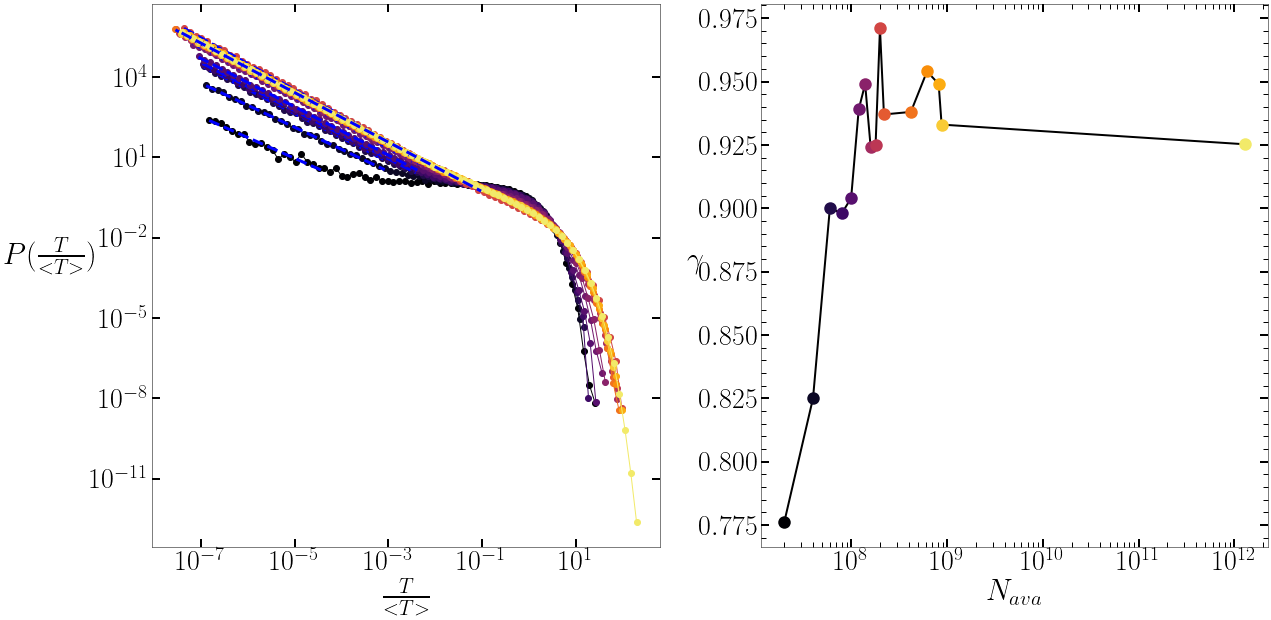

In [27]:
red_nbins = 100
Tnmin = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,1,1,1,1])
Tnmax = np.array([25, 30, 35, 35, 40, 45, 40, 45, 45, 30, 45,45,45,45,45])

NCURVES = len(norm_histo) + 1
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

plt.figure(figsize = (20, 10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

Tb2 = np.zeros(len(norm_histo))

stop = [5e-5,1e-3,1e-3,5e-3,5e-3,
        5e-3,5e-3,5e-3,5e-3,5e-3,
        5e-3,5e-3,5e-3,5e-3, 5e-3]

start_x = [1e-10,1e-10,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10,1e-10]

Tgamma = np.zeros(len(norm_histo))
Tperr = np.zeros(len(norm_histo))

for j, (bins, histo) in enumerate(zip(norm_bin_centers, norm_histo)):


    bins_reduced, histo_reduced_norm = change_bins_log_histo(bins, histo, red_nbins)
    ax1.plot(bins_reduced[:-1][histo_reduced_norm!=0], histo_reduced_norm[histo_reduced_norm!=0], color = colors[j], marker = "o")
    
    """ try:
        popt2, _ = curve_fit(powerlaw2, np.log(bins_reduced[Tnmin[j]:Tnmax[j]][histo_reduced_norm[Tnmin[j]:Tnmax[j]]!=0]),
                             np.log(histo_reduced_norm[Tnmin[j]:Tnmax[j]][histo_reduced_norm[Tnmin[j]:Tnmax[j]]!=0]))
        a2,b2 = popt2
        yfit2 = np.exp(powerlaw2(np.log(bins_reduced[Tnmin[j]:Tnmax[j]]), *popt2))
        
        Tb2[j] = b2
        ax1.plot(bins_reduced[Tnmin[j]:Tnmax[j]], yfit2, linestyle = "--", color = 'b', linewidth = 3)
    
    except ValueError:
        continue """
        
        
    mask = histo_reduced_norm!=0
    
    
    result, xs, _ , perr = fit_powerlaw(bins_reduced[:-1][mask], histo_reduced_norm[mask], stop_x = stop[j], start_x = start_x[j], f_scale=1.0,
                                function_to_fit='power', switch = 1)
    
    ax1.plot(xs, powerlaw(xs, *result.x), 'b--', lw = 3, label='$a={} \pm {}$'.format(np.round(result.x[1], 2),
                                                                        np.round(perr[1], 2)))
    
    Tgamma[j] = np.round(result.x[1], 3)
    Tperr[j] =  np.round(perr[1], 3)
    


################### add the histo of the last  time ######################
bins_reduced, histo_reduced_norm = change_bins_log_histo(bin_center12, histo12, red_nbins)

mask = histo_reduced_norm != 0
ax1.plot(bins_reduced[:-1][mask], histo_reduced_norm[mask], color = colors[-1], marker = "o")

""" try:
    nmin, nmax = 1, 45
    mask2 = histo_reduced_norm[nmin:nmax]!=0
    popt2, _ = curve_fit(powerlaw2, np.log(bins_reduced[:-1][nmin:nmax][mask2]), 
                        np.log(histo_reduced_norm[nmin:nmax][mask2]))
    a2,b2 = popt2
    yfit2 = np.exp(powerlaw2(np.log(bins_reduced[nmin:nmax]), *popt2))
    
    ax1.plot(bins_reduced[nmin:nmax], yfit2, linestyle = "--", color = 'b', linewidth = 3)
    
    # ax2.scatter(time12, -b2, color  = colors[-1], s = 120)
    # Tb22 = np.insert(Tb2, len(Tb2), b2)
    
except ValueError:
    pass """




result, xs, _ , perr = fit_powerlaw(bins_reduced[:-1][mask], histo_reduced_norm[mask], stop_x = 1e-1, start_x = 1e-10, f_scale=1.0,
                            function_to_fit='power', switch = 1)

ax1.plot(xs, powerlaw(xs, *result.x), 'b--', lw = 3, label='$a={} \pm {}$'.format(np.round(result.x[1], 2),
                                                                    np.round(perr[1], 2)))

time2 = np.insert(time, len(time), time12)
Tgamma2 = np.insert(Tgamma, len(Tgamma), result.x[1])
Tperr2 = np.insert(Tperr, len(Tperr), perr[1])
    
    
NCURVES = len(norm_histo) + 1
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]
    
# ax2.plot(time2, -Tb22, lw = 2, c = 'k')
# ax2.scatter(time2, -Tb22, color = colors, marker = 'o', s = 120, zorder = 2)
for i in range(len(time2)):
    # ax2.errorbar(time2[i], -Tgamma2[i], yerr = Tperr2[i], fmt = 'o', color = colors[i], lw =2, markersize = 10)
    ax2.scatter(time2[i], -Tgamma2[i], color = colors[i], lw =2, s = 110, zorder = 3)
ax2.plot(time2, -Tgamma2, lw = 2, c = 'k')
# ax2.scatter(time2, -Tgamma2, color = colors, marker = 'o', s = 120, zorder = 2)


ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_xlabel(r'$\frac{T}{<T>}$', fontsize = 30)
ax1.set_ylabel(r'$P(\frac{T}{<T>})$', fontsize = 30, rotation = 0,labelpad= 40)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.set_xlabel(r'$N_{ava}$', fontsize = 30)
ax2.set_ylabel(r'$\gamma$', fontsize = 30, rotation = 0)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.set_xscale('log')
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.show()